In [2]:
import yfinance as yf
import pandas as pd

ticker = yf.Ticker("AAPL")
df = ticker.history(start="2018-01-01", end="2025-01-01")

print(df.shape)
print(df.head())

(1761, 7)
                                Open       High        Low      Close  \
Date                                                                    
2018-01-02 00:00:00-05:00  39.812835  40.313537  39.602258  40.304176   
2018-01-03 00:00:00-05:00  40.367342  40.839968  40.233980  40.297150   
2018-01-04 00:00:00-05:00  40.369700  40.587297  40.262075  40.484348   
2018-01-05 00:00:00-05:00  40.580254  41.031820  40.489005  40.945251   
2018-01-08 00:00:00-05:00  40.793186  41.087991  40.694914  40.793186   

                              Volume  Dividends  Stock Splits  
Date                                                           
2018-01-02 00:00:00-05:00  102223600        0.0           0.0  
2018-01-03 00:00:00-05:00  118071600        0.0           0.0  
2018-01-04 00:00:00-05:00   89738400        0.0           0.0  
2018-01-05 00:00:00-05:00   94640000        0.0           0.0  
2018-01-08 00:00:00-05:00   82271200        0.0           0.0  


In [3]:
print(df["Close"].describe())

count    1761.000000
mean      121.736451
std        59.063092
min        33.768085
25%        54.043640
50%       131.304428
75%       168.494415
max       257.612762
Name: Close, dtype: float64


In [4]:
df["return"] = df["Close"].pct_change()
print(df["return"].describe())

count    1760.000000
mean        0.001220
std         0.019242
min        -0.128647
25%        -0.008035
50%         0.001276
75%         0.011506
max         0.119808
Name: return, dtype: float64


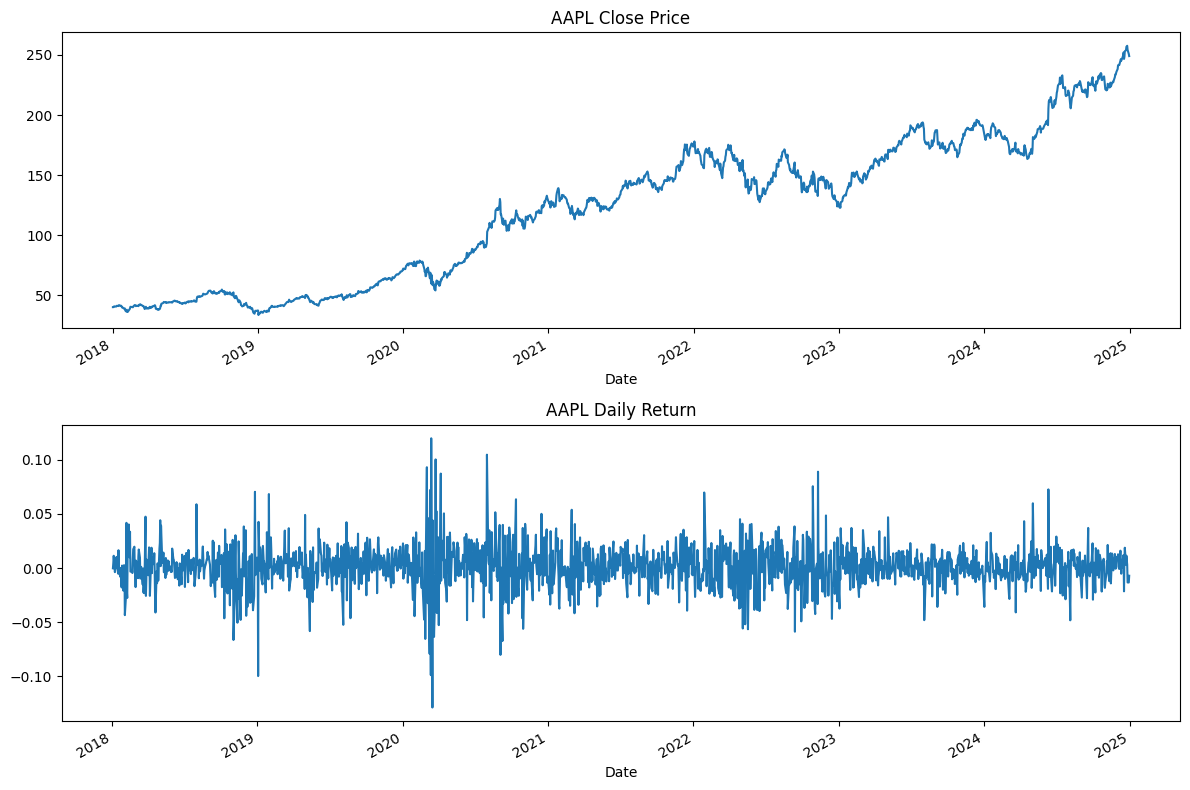

In [5]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
df["Close"]. plot(ax=ax1, title = "AAPL Close Price")
df["return"].plot(ax=ax2, title = "AAPL Daily Return")
plt.tight_layout()
plt.show()

In [10]:
# Feature engineering

# Past returns
df["return_1"] = df["Close"].pct_change(1)
df["return_5"] = df["Close"].pct_change(5)
df["return_10"] = df["Close"].pct_change(10)

# Moving averages: average price level over the last N days
# If today's price is above the moving average, the stock is in a positive trend
df["ma_10"] = df["Close"].rolling(10).mean()
df["ma_50"] = df["Close"].rolling(50).mean()

# Volatility: standard deviation of returns over the last 10 days
df["volatility_10"] = df["return_1"].rolling(10).std()

In [11]:
print(df[["return_1", "return_5", "return_10", "ma_10", "ma_50", "volatility_10"]].tail(10))

                           return_1  return_5  return_10       ma_10  \
Date                                                                   
2024-12-17 00:00:00-05:00  0.009720  0.023046   0.044632  245.708763   
2024-12-18 00:00:00-05:00 -0.021422  0.006329   0.020740  246.210025   
2024-12-19 00:00:00-05:00  0.007015  0.007380   0.027773  246.881357   
2024-12-20 00:00:00-05:00  0.018816  0.025632   0.047974  248.040028   
2024-12-23 00:00:00-05:00  0.003065  0.016850   0.034529  248.887401   
2024-12-24 00:00:00-05:00  0.011478  0.018621   0.042096  249.924736   
2024-12-26 00:00:00-05:00  0.003176  0.044225   0.050834  251.170930   
2024-12-27 00:00:00-05:00 -0.013242  0.023219   0.030771  251.929784   
2024-12-30 00:00:00-05:00 -0.013263 -0.008998   0.016403  252.334570   
2024-12-31 00:00:00-05:00 -0.007058 -0.019000  -0.002470  252.272908   

                                ma_50  volatility_10  
Date                                                  
2024-12-17 00:00:00-05:00

In [12]:
# Target: 1 if tomorrow's return is positive, 0 otherwise
df["target"] = (df["return_1"].shift(-1) > 0).astype(int)

print(df["target"].value_counts())

target
1    946
0    815
Name: count, dtype: int64


In [13]:
# Remove rows with missing values
df = df.dropna()

print(f"Rows after dropna: {len(df)}")
print(df.isnull().sum())

Rows after dropna: 1712
Open             0
High             0
Low              0
Close            0
Volume           0
Dividends        0
Stock Splits     0
return           0
return_1         0
return_5         0
return_10        0
ma_10            0
ma_50            0
volatility_10    0
target           0
dtype: int64
